In [ ]:
from google.colab import files

uploaded = files.upload()

import pandas as pd

df = pd.read_csv("Cbanks_clean.csv")
df.head()

Saving Cbanks_clean.csv to Cbanks_clean.csv


,Branch Number,Branch Name,City,State,Latitude,Longitude,County,Coordinate_Source,Main Office,Established Date,Institution Name,Street Address,Acquired Date,Year,Deposits,log_deposits
0,0,JPMorgan Chase Bank Main Office,Columbus,OH,40.14453,-82.99115,Delaware,Original,1,1824-01-01,JPMorgan Chase Bank,1111 Polaris Parkway,NaN,2010,633131000.0,20.266188
1,2,Vernon Hills Scarsdale Branch,Scarsdale,NY,40.97008,-73.80670,Westchester,Original,0,1961-03-20,JPMorgan Chase Bank,676 White Plains Road,NaN,2010,293229.0,12.588713
2,3,Great Neck Northern Boulevard Branch,Great Neck,NY,40.77944,-73.72240,Nassau,Original,0,1963-09-09,JPMorgan Chase Bank,410 Northern Boulevard,NaN,2010,191011.0,12.160092
3,4,North Hartsdale Branch,Hartsdale,NY,41.02654,-73.79168,Westchester,Original,0,1966-02-19,JPMorgan Chase Bank,353 North Central Avenue,NaN,2010,87110.0,11.374938
4,5,Lawrence Rockaway Branch,Lawrence,NY,40.62715,-73.73675,Nassau,Original,0,1965-01-16,JPMorgan Chase Bank,335 Rockaway Turnpike,NaN,2010,172608.0,12.058784


In [ ]:
model_df = df[
    ["Branch Number", "Branch Name",
     "City", "State", "Year", "Deposits"]
].copy()

In [ ]:

print(model_df.shape)



(37891, 6)


In [ ]:
print(model_df.head())

       Branch Number                      Branch Name      City State  Year  \
0                  0  JPMorgan Chase Bank Main Office  Columbus    OH  2010   
5413               0  JPMorgan Chase Bank Main Office  Columbus    OH  2011   
10826              0  JPMorgan Chase Bank Main Office  Columbus    OH  2012   
16239              0  JPMorgan Chase Bank Main Office  Columbus    OH  2013   
21652              0  JPMorgan Chase Bank Main Office  Columbus    OH  2014   

           Deposits  
0      6.331310e+08  
5413   7.432680e+08  
10826  8.324550e+08  
16239  9.165430e+08  
21652  1.032549e+09  


In [ ]:
print(model_df.dtypes)

Branch Number      int64
Branch Name       object
City              object
State             object
Year               int64
Deposits         float64
dtype: object


In [ ]:
print(model_df["Year"].value_counts().sort_index())

Year
2010    5413
2011    5413
2012    5413
2013    5413
2014    5413
2015    5413
2016    5413
Name: count, dtype: int64


In [ ]:
yearly_deposits = (
    model_df
    .groupby("Year")["Deposits"]
    .agg(["sum", "mean", "median"])
    .reset_index()
)

yearly_deposits

,Year,sum,mean,median
0,2010,1.250793e+09,231072.124885,36823.0
1,2011,1.469636e+09,271501.245151,38708.0
2,2012,1.644969e+09,303892.280159,43616.0
3,2013,1.814057e+09,335129.643081,48350.0
4,2014,2.046407e+09,378054.065952,53873.0
5,2015,2.124107e+09,392408.398393,60016.0
6,2016,2.310370e+09,426818.772954,68157.0


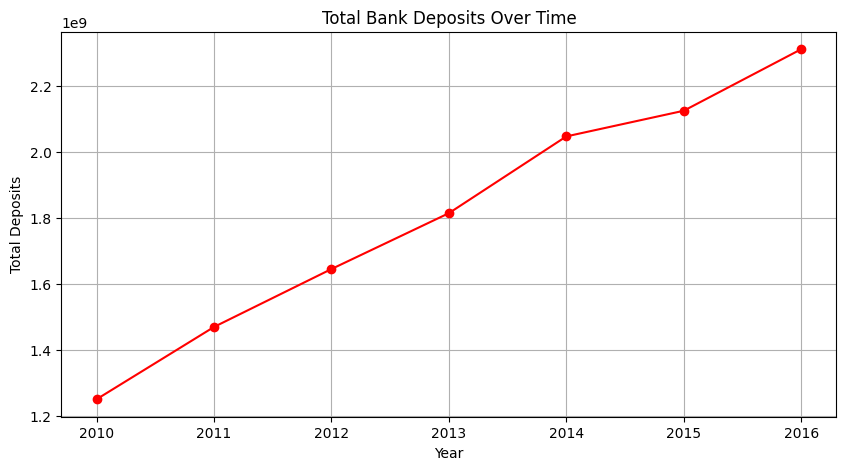

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.plot(
    yearly_deposits["Year"],
    yearly_deposits["sum"],
    marker="o",
    color="red"
)

plt.xlabel("Year")
plt.ylabel("Total Deposits")
plt.title("Total Bank Deposits Over Time")
plt.grid(True)

plt.show()

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# -----------------------------
# Yearly deposits
# -----------------------------

yearly = (
    model_df.groupby("Year")["Deposits"]
    .sum()
    .reset_index()
)

# Growth %
yearly["Growth %"] = (
    yearly["Deposits"].pct_change() * 100
)

print(yearly)

   Year      Deposits   Growth %
0  2010  1.250793e+09        NaN
1  2011  1.469636e+09  17.496321
2  2012  1.644969e+09  11.930345
3  2013  1.814057e+09  10.279091
4  2014  2.046407e+09  12.808304
5  2015  2.124107e+09   3.796899
6  2016  2.310370e+09   8.769021


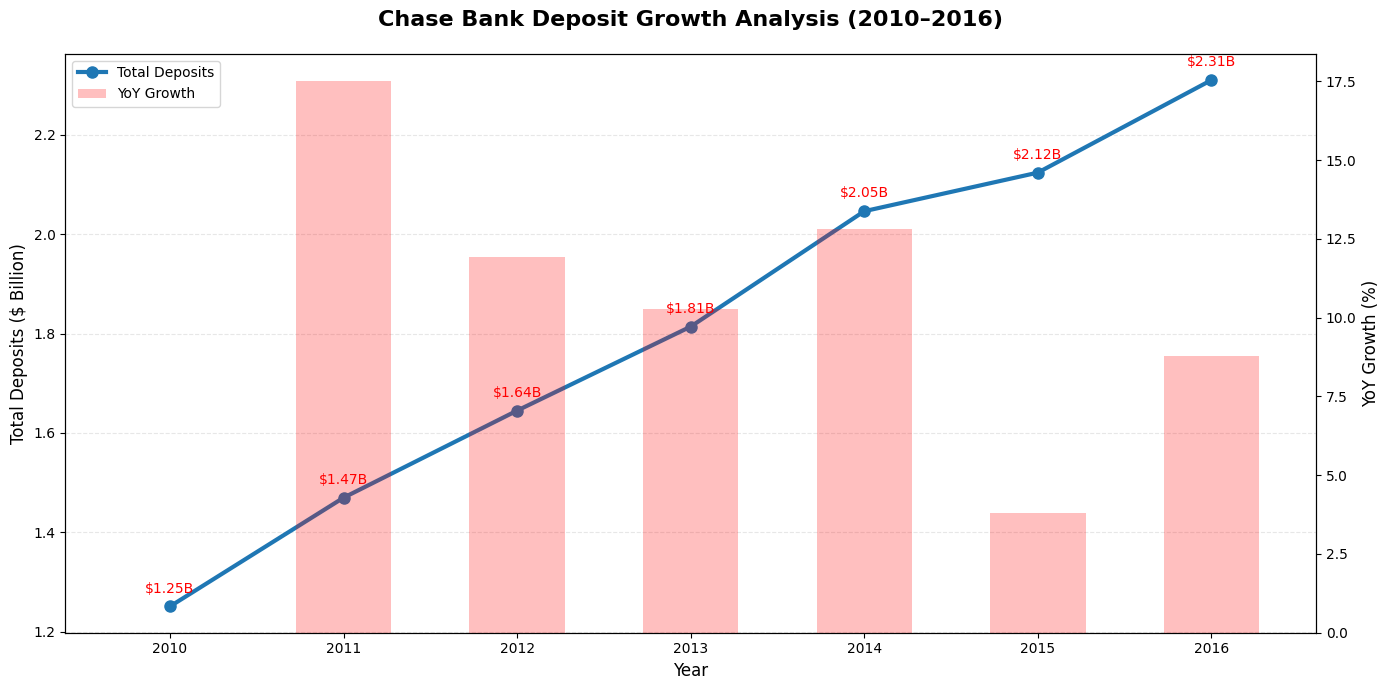

In [ ]:
fig, ax1 = plt.subplots(figsize=(14, 7))

# Deposits
ax1.plot(
    yearly["Year"],
    yearly["Deposits"] / 1e9,
    marker="o",
    linewidth=3,
    markersize=8,
    label="Total Deposits"
)

ax1.set_xlabel("Year", fontsize=12)
ax1.set_ylabel("Total Deposits ($ Billion)", fontsize=12)

ax1.set_xticks(yearly["Year"])

# Labels
for x, y in zip(
    yearly["Year"],
    yearly["Deposits"] / 1e9
):
    ax1.annotate(
        f"${y:.2f}B",
        (x, y),
        xytext=(0, 10),
        textcoords="offset points",
        ha="center",
        fontsize=10,
        color="red"
    )

# Growth
ax2 = ax1.twinx()

ax2.bar(
    yearly["Year"],
    yearly["Growth %"].fillna(0),
    alpha=0.25,
    width=0.55,
    label="YoY Growth",
    color="red"
)

ax2.set_ylabel("YoY Growth (%)", fontsize=12)

# Title
plt.title(
    "Chase Bank Deposit Growth Analysis (2010–2016)",
    fontsize=16,
    fontweight="bold",
    pad=20
)

ax1.grid(
    axis="y",
    linestyle="--",
    alpha=0.3
)

# Combined legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()

ax1.legend(
    lines1 + lines2,
    labels1 + labels2,
    loc="upper left"
)

plt.tight_layout()
plt.show()

In [ ]:
yearly_deposits["growth_pct"] = (
    yearly_deposits["sum"].pct_change() * 100
)

yearly_deposits

,Year,sum,mean,median,growth_pct
0,2010,1.250793e+09,231072.124885,36823.0,NaN
1,2011,1.469636e+09,271501.245151,38708.0,17.496321
2,2012,1.644969e+09,303892.280159,43616.0,11.930345
3,2013,1.814057e+09,335129.643081,48350.0,10.279091
4,2014,2.046407e+09,378054.065952,53873.0,12.808304
5,2015,2.124107e+09,392408.398393,60016.0,3.796899
6,2016,2.310370e+09,426818.772954,68157.0,8.769021


In [ ]:
model_df["Deposits"].describe()

,Deposits
count,3.789100e+04
mean,3.341252e+05
std,1.308214e+07
min,0.000000e+00
25%,2.489900e+04
50%,4.974000e+04
75%,9.596200e+04
max,1.155185e+09


In [ ]:
#right skeweed


print(
    model_df["Deposits"].quantile(
        [0.90, 0.95, 0.99, 0.995, 0.999]
    )
)

0.900    1.712010e+05
0.950    2.421195e+05
0.990    5.584610e+05
0.995    1.007291e+06
0.999    2.219629e+07
Name: Deposits, dtype: float64


In [ ]:
Q1 = model_df["Deposits"].quantile(0.25)
Q3 = model_df["Deposits"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = model_df[
    (model_df["Deposits"] < lower) |
    (model_df["Deposits"] > upper)
]

print("Number of outliers:", len(outliers))
print("Upper bound:", upper)

Number of outliers: 2720
Upper bound: 202556.5


In [ ]:
import numpy as np

model_df["log_deposits"] = np.log1p(
    model_df["Deposits"]
)

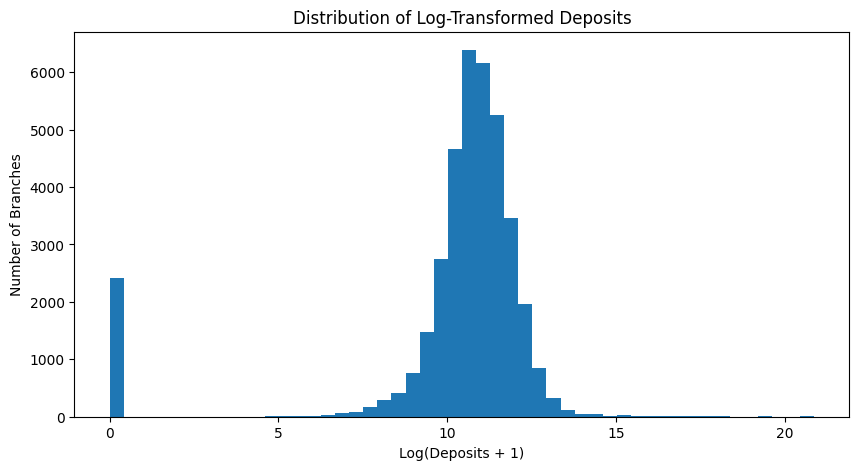

In [ ]:
plt.figure(figsize=(10, 5))

plt.hist(
    model_df["log_deposits"],
    bins=50
)

plt.xlabel("Log(Deposits + 1)")
plt.ylabel("Number of Branches")
plt.title("Distribution of Log-Transformed Deposits")

plt.show()

In [ ]:

model_df[
    ["Deposits", "log_deposits"]
].describe()

,Deposits,log_deposits
count,3.789100e+04,37891.000000
mean,3.341252e+05,10.180770
std,1.308214e+07,2.852236
min,0.000000e+00,0.000000
25%,2.489900e+04,10.122623
50%,4.974000e+04,10.814585
75%,9.596200e+04,11.471718
max,1.155185e+09,20.867526


In [ ]:
model_df = model_df.sort_values(
    ["Branch Number", "Year"]
).copy()

lag one current year woith previous year

In [ ]:
model_df["lag_1"] = (
    model_df
    .groupby("Branch Number")["log_deposits"]
    .shift(1)
)

lag two current year with previous two years e Q4 2010 with Q2 2010

In [ ]:
model_df["lag_2"] = (
    model_df
    .groupby("Branch Number")["log_deposits"]
    .shift(2)
)

lag three

In [ ]:
model_df["lag_3"] = (
    model_df
    .groupby("Branch Number")["log_deposits"]
    .shift(3)
)

lag four

In [ ]:
model_df["lag_3"] = (
    model_df
    .groupby("Branch Number")["log_deposits"]
    .shift(4)
)

In [ ]:
#deposit growth by log_deposits
model_df["growth"] = (
    model_df
    .groupby("Branch Number")["log_deposits"]
    .diff()
)

In [ ]:
#rolling mean prevent data leakage
model_df["rolling_mean_3"] = (
    model_df
    .groupby("Branch Number")["log_deposits"]
    .transform(
        lambda x: x.shift(1).rolling(3).mean()
    )
)

In [ ]:
model_df[
    [
        "Branch Number",
        "Year",
        "Deposits",
        "log_deposits",
        "lag_1",
        "lag_2",
        "lag_3",
        "growth",
        "rolling_mean_3"
    ]
].head(10)

,Branch Number,Year,Deposits,log_deposits,lag_1,lag_2,lag_3,growth,rolling_mean_3
0,0,2010,6.331310e+08,20.266188,NaN,NaN,NaN,NaN,NaN
5413,0,2011,7.432680e+08,20.426567,20.266188,NaN,NaN,0.160379,NaN
10826,0,2012,8.324550e+08,20.539890,20.426567,20.266188,NaN,0.113322,NaN
16239,0,2013,9.165430e+08,20.636120,20.539890,20.426567,NaN,0.096230,20.410882
21652,0,2014,1.032549e+09,20.755296,20.636120,20.539890,20.266188,0.119177,20.534192
27065,0,2015,1.069425e+09,20.790387,20.755296,20.636120,20.426567,0.035091,20.643769
32478,0,2016,1.155185e+09,20.867526,20.790387,20.755296,20.539890,0.077139,20.727268
1,2,2010,2.932290e+05,12.588713,NaN,NaN,NaN,NaN,NaN
5414,2,2011,3.107910e+05,12.646879,12.588713,NaN,NaN,0.058167,NaN
10827,2,2012,3.257420e+05,12.693864,12.646879,12.588713,NaN,0.046985,NaN


In [ ]:
features = [
    "lag_1",
    "lag_2",
    "lag_3",
    "growth",
    "rolling_mean_3"
]

target = "log_deposits"

ml_df = model_df.dropna(
    subset=features + [target]
).copy()

print(ml_df.shape)

(16239, 12)


In [ ]:
print(ml_df.columns.tolist())

['Branch Number', 'Branch Name', 'City', 'State', 'Year', 'Deposits', 'log_deposits', 'lag_1', 'lag_2', 'lag_3', 'growth', 'rolling_mean_3']


In [ ]:
#split into train and test
train = ml_df[
    ml_df["Year"] <= 2015
].copy()

test = ml_df[
    ml_df["Year"] > 2015
].copy()

print("Train:", train.shape)
print("Test:", test.shape)

Train: (10826, 12)
Test: (5413, 12)


In [ ]:
X_train = train[features]
y_train = train[target]

X_test = test[features]
y_test = test[target]

In [ ]:
!pip install xgboost

In [ ]:
from xgboost import XGBRegressor

model = XGBRegressor(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    random_state=42
)

model.fit(
    X_train,
    y_train
)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=True, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=4,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=300,
             n_jobs=None, num_parallel_tree=None, ...)

In [ ]:
y_pred_log = model.predict(X_test)

In [ ]:
import numpy as np

y_pred = np.expm1(y_pred_log)
y_actual = np.expm1(y_test)

In [ ]:
print(X_test.columns.tolist())

['lag_1', 'lag_2', 'lag_3', 'growth', 'rolling_mean_3']


In [ ]:
results = X_test.copy()

results["Actual"] = y_test
results["Predicted"] = y_pred

results["Predicted_Increase"] = (
    results["Predicted"] > results["lag_1"]
)

results["Actual_Increase"] = (
    results["Actual"] > results["lag_1"]
)

results["Correct_Direction"] = (
    results["Predicted_Increase"] ==
    results["Actual_Increase"]
)

In [ ]:
print(results[
    ["lag_1", "Actual", "Predicted",
     "Predicted_Increase",
     "Actual_Increase",
     "Correct_Direction"]
].head(20))

           lag_1     Actual     Predicted  Predicted_Increase  \
32478  20.790387  20.867526  7.975481e+07                True   
32479  12.741033  12.852021  3.928859e+05                True   
32480  12.477839  12.538756  2.700007e+05                True   
32481  11.667987  11.851068  1.385329e+05                True   
32482  12.315828  12.369870  2.332886e+05                True   
32483  11.887931  11.931307  1.524185e+05                True   
32484  11.582144  11.613612  1.084754e+05                True   
32485  10.945424  11.050795  6.258908e+04                True   
32486  11.323664  11.395886  8.867166e+04                True   
32487  11.338322  11.392733  8.820045e+04                True   
32488  12.806106  12.867043  3.787344e+05                True   
32489  12.003571  12.098304  1.796981e+05                True   
32490  11.809141  11.787112  1.316727e+05                True   
32491  12.120215  12.178753  1.938340e+05                True   
32492  12.537346  12.6042

In [ ]:
print("Actual:")
print(y_test.head())

print("\nPredicted:")
print(y_pred_log[:5])

print("\nLag 1:")
print(X_test["lag_1"].head())

Actual:
32478    20.867526
32479    12.852021
32480    12.538756
32481    11.851068
32482    12.369870
Name: log_deposits, dtype: float64

Predicted:
[18.194468 12.881277 12.506184 11.83887  12.360036]

Lag 1:
32478    20.790387
32479    12.741033
32480    12.477839
32481    11.667987
32482    12.315828
Name: lag_1, dtype: float64


In [ ]:
print(results["Predicted_Increase"].value_counts())

Predicted_Increase
True     5271
False     142
Name: count, dtype: int64


In [ ]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

mae = mean_absolute_error(
    y_actual,
    y_pred
)

rmse = np.sqrt(
    mean_squared_error(
        y_actual,
        y_pred
    )
)

r2 = r2_score(
    y_actual,
    y_pred
)

print("MAE:", mae)
print("RMSE:", rmse)
print("R²:", r2)

MAE: 326834.29091804504
RMSE: 15273293.89440566
R²: 0.12500629131774432


use baseline to compare it with model current deposits = predicted

In [ ]:
test_baseline = test.copy()

test_baseline["pred_log"] = test_baseline["lag_1"]

baseline_pred = np.expm1(
    test_baseline["pred_log"]
)

baseline_actual = np.expm1(
    test_baseline["log_deposits"]
)

In [ ]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)
import numpy as np

baseline_mae = mean_absolute_error(
    baseline_actual,
    baseline_pred
)

baseline_rmse = np.sqrt(
    mean_squared_error(
        baseline_actual,
        baseline_pred
    )
)

baseline_r2 = r2_score(
    baseline_actual,
    baseline_pred
)

print("Baseline MAE:", baseline_mae)
print("Baseline RMSE:", baseline_rmse)
print("Baseline R²:", baseline_r2)

Baseline MAE: 45874.442545723374
Baseline RMSE: 1391984.361026304
Baseline R²: 0.9927321120183672


In [ ]:
nyc_df = model_df[
    (model_df["City"].str.strip().str.lower() == "new york city") &
    (model_df["State"].str.strip().str.upper() == "NY")
].copy()

print(nyc_df.shape)
print(nyc_df["Branch Number"].nunique())

(1078, 12)
154


In [ ]:
print(
    nyc_df.groupby("Year")["Branch Number"].nunique()
)

Year
2010    154
2011    154
2012    154
2013    154
2014    154
2015    154
2016    154
Name: Branch Number, dtype: int64


In [ ]:
nyc_df = nyc_df.sort_values(
    ["Branch Number", "Year"]
).copy()

In [ ]:
nyc_df["lag_1"] = (
    nyc_df.groupby("Branch Number")["log_deposits"]
    .shift(1)
)

nyc_df["lag_2"] = (
    nyc_df.groupby("Branch Number")["log_deposits"]
    .shift(2)
)

nyc_df["lag_3"] = (
    nyc_df.groupby("Branch Number")["log_deposits"]
    .shift(3)
)

nyc_df["growth"] = (
    nyc_df.groupby("Branch Number")["log_deposits"]
    .diff()
)

nyc_df["rolling_mean_3"] = (
    nyc_df.groupby("Branch Number")["log_deposits"]
    .transform(
        lambda x: x.shift(1).rolling(3).mean()
    )
)

In [ ]:
features = [
    "lag_1",
    "lag_2",
    "lag_3",
    "growth",
    "rolling_mean_3"
]

target = "log_deposits"

nyc_ml = nyc_df.dropna(
    subset=features + [target]
).copy()

train = nyc_ml[nyc_ml["Year"] <= 2014]
test = nyc_ml[nyc_ml["Year"] >= 2015]

X_train = train[features]
y_train = train[target]

X_test = test[features]
y_test = test[target]

print("Train:", X_train.shape)
print("Test:", X_test.shape)

Train: (308, 5)
Test: (308, 5)


In [ ]:
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Actual deposits
actual = np.expm1(test["log_deposits"])


print("Actual:", actual.shape)

Actual: (308,)


In [ ]:
from xgboost import XGBRegressor

xgb_model = XGBRegressor(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    random_state=42
)

xgb_model.fit(X_train, y_train)

pred_log = xgb_model.predict(X_test)

pred = np.expm1(pred_log)

In [ ]:
xgb_mae = mean_absolute_error(actual, pred)

xgb_rmse = np.sqrt(
    mean_squared_error(actual, pred)
)

xgb_r2 = r2_score(actual, pred)

print("NYC XGBoost")
print("MAE:", xgb_mae)
print("RMSE:", xgb_rmse)
print("R²:", xgb_r2)

NYC XGBoost
MAE: 788390.7332626203
RMSE: 7178896.819551265
R²: 0.9101379907750923


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# -----------------------------
# 1. NYC yearly deposits
# -----------------------------

nyc_yearly = (
    nyc_df.groupby("Year")["Deposits"]
    .sum()
    .reset_index()
)

# Year-over-Year Growth
nyc_yearly["Growth %"] = (
    nyc_yearly["Deposits"].pct_change() * 100
)

print(nyc_yearly)

   Year     Deposits   Growth %
0  2010  230565970.0        NaN
1  2011  295510226.0  28.167321
2  2012  333313772.0  12.792635
3  2013  358578146.5   7.579757
4  2014  391311875.0   9.128757
5  2015  405224010.0   3.555255
6  2016  454921964.0  12.264316


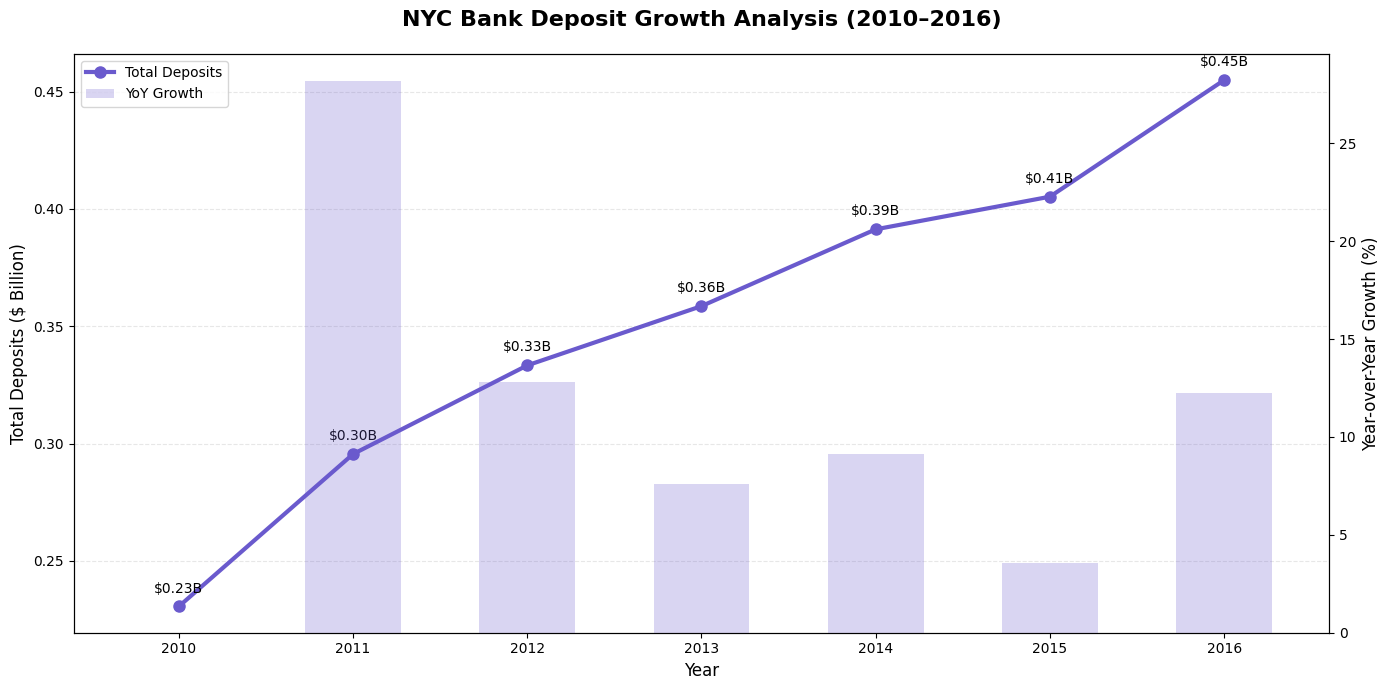

In [ ]:
import matplotlib.pyplot as plt
fig, ax1 = plt.subplots(figsize=(14, 7))

# -----------------------------
# Deposits Line
# -----------------------------

ax1.plot(
    nyc_yearly["Year"],
    nyc_yearly["Deposits"] / 1e9,
    marker="o",
    linewidth=3,
    markersize=8,
    label="Total Deposits",
    color="#6A5ACD",
)

ax1.set_xlabel("Year", fontsize=12)
ax1.set_ylabel("Total Deposits ($ Billion)", fontsize=12)

ax1.set_xticks(nyc_yearly["Year"])

# Add deposit values
for x, y in zip(
    nyc_yearly["Year"],
    nyc_yearly["Deposits"] / 1e9
):
    ax1.annotate(
        f"${y:.2f}B",
        (x, y),
        xytext=(0, 10),
        textcoords="offset points",
        ha="center",
        fontsize=10
    )

# -----------------------------
# Growth %
# -----------------------------

ax2 = ax1.twinx()

ax2.bar(
    nyc_yearly["Year"],
    nyc_yearly["Growth %"].fillna(0),
    alpha=0.25,
    width=0.55,
    label="YoY Growth",
    color="#6A5ACD"
)

ax2.set_ylabel("Year-over-Year Growth (%)", fontsize=12)

# -----------------------------
# Title
# -----------------------------

plt.title(
    "NYC Bank Deposit Growth Analysis (2010–2016)",
    fontsize=16,
    fontweight="bold",
    pad=20
)

# Grid
ax1.grid(
    axis="y",
    linestyle="--",
    alpha=0.3
)

# Combined legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()

ax1.legend(
    lines1 + lines2,
    labels1 + labels2,
    loc="upper left"
)

plt.tight_layout()
plt.show()